In [29]:
import warnings

def fxn():
    warnings.warn("deprecated", DeprecationWarning)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()

In [30]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from matplotlib.pyplot import plot, ion, show, savefig, cla, figure
from pathlib import Path
from tqdm import tqdm

from data_loader import DataGenerator
from models import VAELSTMModel
from trainers import VAELSTMTrainer
from train import load_latest_vae_checkpoint, set_random_seeds
from utils import process_config, create_dirs

In [31]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"   # keep GPU ordering consistent
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [32]:
# load VAE model
config = process_config('config.json')
# create the experiments dirs
create_dirs([config['result_dir'], config['checkpoint_dir']])
# create your data generator
data = DataGenerator(config)

In [33]:
seed = config.get('random_seed', 42)
set_random_seeds(seed)

In [34]:
# create a VAE model and load the latest checkpoint
vae_model = VAELSTMModel(config).to(device)
vae_trainer = VAELSTMTrainer(vae_model, data, config)

load_latest_vae_checkpoint(vae_trainer, config['checkpoint_dir'])

vae_model.eval()

No checkpoint found at experiments/local-results/WESAD/batch-2048/WESAD-48-12-6/checkpoint/experiments/local-results/WESAD/batch-2048/WESAD-48-12-6/checkpoint/vae_checkpoint_epoch_100.pth
Loaded VAE checkpoint: experiments/local-results/WESAD/batch-2048/WESAD-48-12-6/checkpoint/vae_checkpoint_epoch_100.pth


VAELSTMModel(
  (vae): VAEmodel(
    (encoder): VAEEncoder(
      (enc_conv1): Conv2d(67, 32, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
      (enc_conv2): Conv2d(32, 64, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
      (enc_conv3): Conv2d(64, 128, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
      (enc_conv4): Conv2d(128, 512, kernel_size=(6, 1), stride=(1, 1))
      (enc_fc): Linear(in_features=512, out_features=24, bias=True)
      (enc_fc_mean): Linear(in_features=24, out_features=6, bias=True)
      (enc_fc_std): Linear(in_features=24, out_features=6, bias=True)
    )
    (decoder): VAEDecoder(
      (dec_fc): Linear(in_features=6, out_features=512, bias=True)
      (dec_conv1): Conv2d(512, 768, kernel_size=(1, 1), stride=(1, 1))
      (dec_conv2): Conv2d(256, 256, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
      (dec_conv3): Conv2d(128, 128, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
      (dec_conv4): Conv2d(32, 32, kernel_size=(3, 1), strid

In [35]:
# load normalised time series
data_dir = Path('../data/')

train_df = pd.read_csv(data_dir / 'train.csv')
train_df = train_df.drop(columns=['label', 'subject_id'])
train_m = train_df.mean()
train_std = train_df.std()

test_df = pd.read_csv(data_dir / 'test.csv')
test_subjects = test_df.pop('subject_id')
test_label = test_df.pop('label')
test_df_normalized = (test_df - train_m) / train_std

result = {}
result['test'] = test_df_normalized.to_numpy()
result['idx_anomaly_test'] = test_label[test_label == 1].index.to_numpy()
result['train_m'] = train_m.values[0]
result['train_std'] = train_std.values[0]
result['t_unit'] = '0.25 sec'
result['t_test'] = np.arange(len(test_df_normalized))

n_val = len(data.val_set)
n_test = len(data.test_set)

train_set_loader, val_set_loader, test_set_loader = data.get_dataloaders(test=True)

In [ ]:
# Evaluate ELBO and LSTM prediction error on the validation set
# evaluate some anomaly detection metrics
def evaluate_model(data_loader):
    batch_recons_error = []
    batch_vae_kl = []
    
    for batch_data in tqdm(data_loader):
        if isinstance(batch_data, (list, tuple)):
            batch_data = batch_data[0]
        
        batch_data = batch_data.to(device)
        
        with torch.no_grad():
            recon_batch, latent_mean, latent_std = vae_model(batch_data)
            
            recons_error = torch.sum((recon_batch - batch_data[:, 1:, :]).pow(2), dim=[1,2,3]).cpu().numpy()
            safe_std = torch.clamp(latent_std, min=1e-9)
            vae_kl = 0.5 * (
                torch.sum(latent_mean.pow(2), dim=[1,2])
                + torch.sum(safe_std.pow(2), dim=[1,2])
                - torch.sum(torch.log(safe_std.pow(2)), dim=[1,2])
                - config['code_size']
            ).cpu().numpy()
            
        batch_recons_error.append(recons_error)
        batch_vae_kl.append(vae_kl)
    
    return np.concatenate(batch_recons_error), np.concatenate(batch_vae_kl)

val_recons_error, val_kl_error = evaluate_model(val_set_loader)

100%|██████████| 11/11 [00:01<00:00,  9.94it/s]


In [36]:
from scipy.stats import norm
def plot_histogram(test_anomaly_metric, n_bins, title, mean=None, std=None, xlim=None, saveplot=False):
    test_anomaly_list = np.squeeze(np.ndarray.flatten(test_anomaly_metric))
    his = plt.hist(test_anomaly_list, bins=n_bins, density=True)
    if mean is None and std is None:
        mean = np.mean(test_anomaly_list)
        std = np.std(test_anomaly_list)
        legend_label = None
    else:
        legend_label = 1
    x_axis = np.arange(mean-5*std, mean+5*std, std/100)
    plt.plot(x_axis, norm.pdf(x_axis,mean,std))
    plt.title(title)
    plt.xlabel('anomaly score value')
    plt.ylabel('probability density')
    if xlim is not None:
        plt.xlim(0, xlim)
    else:
        plt.xlim(0, np.amax(test_anomaly_list))
    if legend_label is None:
        plt.legend(('Fitted Gaussian', 'histogram'))
    else:
        plt.legend(('normal data distribution','test data distribution (contain anomalies)'))
    if saveplot:
        savefig(config['result_dir']+'reconstruction_error_histogram.pdf')
    else:
        plt.show()
    threshold_25 = np.percentile(test_anomaly_list, 25)
    threshold_50 = np.percentile(test_anomaly_list, 50)
    threshold_75 = np.percentile(test_anomaly_list, 75)
    threshold_99 = np.percentile(test_anomaly_list, 99)
    idx_large_error = np.squeeze(np.argwhere(test_anomaly_metric > threshold_99))
#     print(his[0][-20:])
#     print(his[1][-20:])
    print("25% percentile: {}".format(threshold_25))
    print("50% percentile: {}".format(threshold_50))
    print("75% percentile: {}".format(threshold_75))
    print("Mean: {}".format(np.mean(test_anomaly_list)))
    print("Std dev: {}".format(np.std(test_anomaly_list)))
    print("These windows scored the top 1% of anomaly metric ({}): \n{}".format(threshold_99, idx_large_error))
    return mean, std

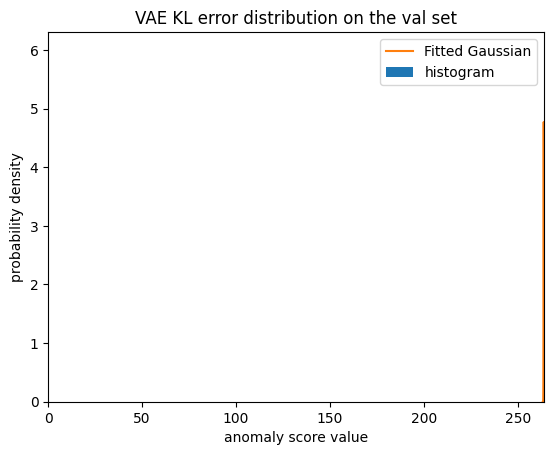

25% percentile: 263.6334228515625
50% percentile: 263.68280029296875
75% percentile: 263.7313232421875
Mean: 263.67718505859375
Std dev: 0.08361037075519562
These windows scored the top 1% of anomaly metric (263.8485412597656): 
[  30   83  134  150  296  348  474 1473 1625 1674 1702 1729 1813 1895
 1906 2030 2167 2215 2325 2393 2423 2437 2636 2724 2870 3017 3054 3255
 3286 3382 3537 3623 3774 3806 3826 3828 4006 4016 4019 4034 4131 4357
 4451 4482 4515 4559 4702 4758 4840 4844 4860 4955 5125 5221 5307 5445]


In [37]:
# Histogram of VAE KL loss - validation set
vae_elbo_m, vae_elbo_std = plot_histogram(val_kl_error, 100, 
                                          'VAE KL error distribution on the val set', 
                                          mean=None, std=None, xlim=None)

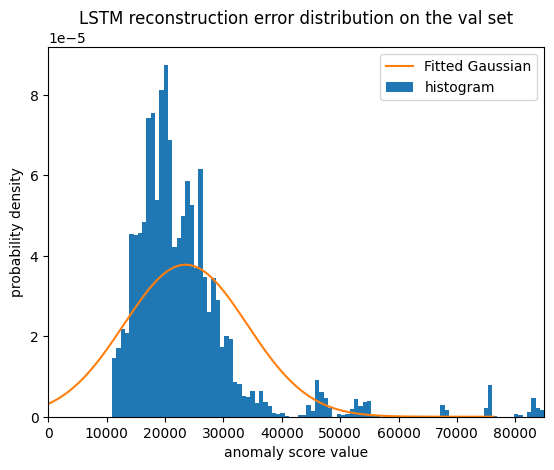

25% percentile: 17646.7265625
50% percentile: 21039.06640625
75% percentile: 26076.96875
Mean: 23524.015625
Std dev: 10564.1611328125
These windows scored the top 1% of anomaly metric (75781.515625): 
[  34   59  134  208  508  513  651 1079 1292 1380 1639 1684 1708 1810
 1865 1939 1954 2028 2097 2417 2426 2576 2662 2713 2763 2781 2932 3043
 3095 3295 3514 3528 3537 3749 3786 3802 3841 3855 3877 3900 3985 4408
 4412 4476 4502 4582 4701 4777 4888 4923 4938 4949 4963 5221 5254 5497]


In [38]:
# Histogram of LSTM reconstruction error - validation set 
#  --> to decide the anomaly detection threshold
lstm_recons_m, lstm_recons_std = plot_histogram(val_recons_error, 100,  
                                              'LSTM reconstruction error distribution on the val set', 
                                              mean=None, std=None, xlim=None)

In [39]:
# Evaluate the anomaly metrics on the test windows and sequences

test_recons_error, test_kl_error = evaluate_model(test_set_loader)

print("All windows' reconstruction error is computed.")
print("The total number of windows is {}".format(len(test_recons_error)))

100%|██████████| 22/22 [00:06<00:00,  3.24it/s]

All windows' reconstruction error is computed.
The total number of windows is 44157


25% percentile: 25018.7265625
50% percentile: 35275.0703125
75% percentile: 61028.796875
Mean: 61988.390625
Std dev: 75697.3203125
These windows scored the top 1% of anomaly metric (357973.90625): 
[  130   131   159   163   164   165   166   167  1050  1051  1079  1083
  1084  1085  1086  1087  1970  1971  1998  1999  2003  2004  2005  2006
  2007  2890  2891  2918  2919  2923  2924  2925  2926  2927  3810  3811
  3838  3839  3843  3844  3845  3846  3847  4730  4731  4758  4759  4763
  4764  4765  4766  4767  5650  5651  5678  5679  5683  5684  5685  5686
  5687  6570  6571  6598  6599  6603  6604  6605  6606  6607  7490  7491
  7519  7523  7524  7525  7526  7527  8410  8411  8438  8439  8443  8444
  8445  8446  8447  9330  9331  9358  9359  9363  9364  9365  9366  9367
 10250 10251 10278 10279 10283 10284 10285 10286 10287 11170 11171 11198
 11199 11203 11204 11205 11206 11207 12090 12091 12118 12119 12123 12124
 12125 12126 12127 13010 13011 13038 13039 13043 13044 13045 13046 13047

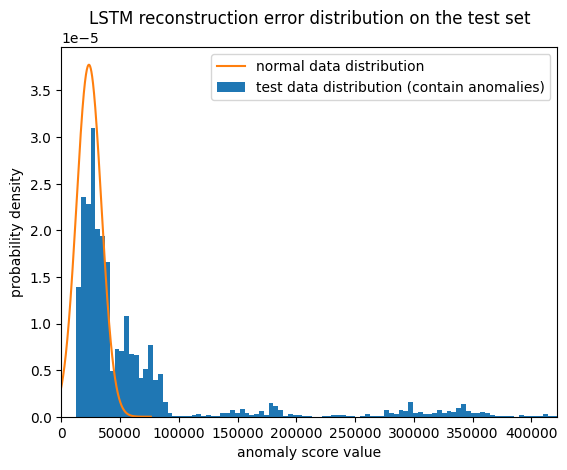

In [40]:
# Histogram of LSTM reconstruction error - test set 
#  --> to detect anomaly now
_, _ = plot_histogram(test_recons_error, 100,
                      'LSTM reconstruction error distribution on the test set', 
                      mean=lstm_recons_m, std=lstm_recons_std, xlim=None, saveplot=True)

In [41]:
idx_anomaly_test = result['idx_anomaly_test']
anomaly_index_lstm = []
test_labels_lstm = np.zeros(n_test)
for i in tqdm(range(len(idx_anomaly_test))):
    idx_start = idx_anomaly_test[i]-(config['l_win']*config['l_seq']-1)
    idx_end = idx_anomaly_test[i]+1
    if idx_start < 0:
        idx_start = 0
    if idx_end > n_test:
        idx_end = n_test
    anomaly_index_lstm.append(np.arange(idx_start,idx_end))
    test_labels_lstm[idx_start:idx_end] = 1
    
print(test_labels_lstm.shape)

100%|██████████| 13684/13684 [00:00<00:00, 426169.89it/s]

(44157,)


In [42]:
def return_anomaly_idx_by_threshold(test_anomaly_metric, threshold):
    idx_error = np.flatnonzero(test_anomaly_metric > threshold)
    if len(idx_error.shape) == 0:
        idx_error = np.expand_dims(idx_error, 0)
    return idx_error

In [43]:
# Augment the detected anomaly indices based on the known anomaly windows
# If any part of a known anomaly window is detected, mark the entire window as detected
# This helps to improve recall in scenarios where anomalies span multiple windows
# and only a portion of the anomaly is detected.
def augment_detected_idx(idx_detected_anomaly, anomaly_index):
    idx_detected_anomaly_set = set(idx_detected_anomaly)
    idx_detected_anomaly_extended = set(idx_detected_anomaly)
    
    # anomaly_index는 이상 구간(리스트의 리스트)이라고 가정 (ground truth)
    for anomaly_win in anomaly_index:
        # 현재 이상 구간(anomaly_win)이 모델의 탐지 구간(idx_detected_anomaly)과 겹치는지 확인
        # set intersection 연산이 빠름
        if idx_detected_anomaly_set.intersection(anomaly_win):
            # 포함되었다면 해당 구간 전체를 확장된 탐지 구간 set에 추가
            idx_detected_anomaly_extended.update(anomaly_win)

    # numpy로 변환 후 정렬
    return np.sort(np.array(list(idx_detected_anomaly_extended), dtype=int))

In [44]:
def count_TP_FP_FN(idx_detected_anomaly, anomaly_index, test_labels):  
    detected_labels = test_labels[idx_detected_anomaly]
    n_TP = np.sum(detected_labels == 1)
    n_FP = np.sum(detected_labels == 0)
    n_FN = np.sum(test_labels == 1) - n_TP
    
    return n_TP, n_FP, n_FN

In [45]:
def compute_precision_and_recall(idx_detected_anomaly, anomaly_index, test_labels):
    n_TP, n_FP, n_FN = count_TP_FP_FN(idx_detected_anomaly, anomaly_index, test_labels)
    
    precision = n_TP / (n_TP + n_FP) if (n_TP + n_FP) > 0 else 1.0
    recall = n_TP / (n_TP + n_FN) if (n_TP + n_FN) > 0 else 0.0
    F1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return precision, recall, F1, n_TP, n_FP, n_FN

In [46]:
# Now select a threshold
threshold = np.percentile(val_recons_error, 100)

print("Threshold is {}".format(threshold))
idx_detection = return_anomaly_idx_by_threshold(test_recons_error, threshold)
idx_detection_augmented = augment_detected_idx(idx_detection, anomaly_index_lstm)
precision, recall, F1, n_TP, n_FP, n_FN = compute_precision_and_recall(idx_detection_augmented, 
                                                                       anomaly_index_lstm, 
                                                                       test_labels_lstm)
print("\nPR evaluation using augmented detection:")
print("Precision: {}".format(precision))
print("Recall: {}".format(recall))
print("F1: {}".format(F1))
print("TP: {}".format(n_TP))
print("FP: {}".format(n_FP))
print("FN: {}".format(n_FN))

Threshold is 84929.1875

PR evaluation using augmented detection:
Precision: 0.817094366629179
Recall: 1.0
F1: 0.8993416980813593
TP: 15984
FP: 3578
FN: 0


In [47]:
def slice_detected_indices_into_seq(idx_detection, interval):
    detected_seq = []
    i = 0
    while i < len(idx_detection):
        if i == 0:
            cur_seq = [idx_detection[i]]
            i = i + 1
        else:
            if idx_detection[i] - idx_detection[i-1] > interval:
                detected_seq.append(cur_seq)
                cur_seq = [idx_detection[i]]
            else:
                cur_seq.append(idx_detection[i])
                if i == len(idx_detection) - 1:
                    detected_seq.append(cur_seq)
            i = i + 1
    
    print("Detected {} sequences".format(len(detected_seq)))
    return detected_seq

In [48]:
def plot_detected_anomalies(idx_detection, interval, result, detection_method, augmented_flag=1, y_scale=5, y_lim=None):
    detected_seq = slice_detected_indices_into_seq(idx_detection, interval=interval)
    t_test = result['t_test']
    test = result['test']
    idx_anomaly_test = result['idx_anomaly_test']
        
    # plot detected sequences
    fig, axs = plt.subplots(1, 1, figsize=(18, 5), edgecolor='k')
    fig.subplots_adjust(hspace=.4, wspace=.4)
    axs.plot(t_test, test[:, 0]) # plot only the first channel
    for j in range(len(idx_anomaly_test)):
        if j == 0:
            axs.plot(idx_anomaly_test[j] * np.ones(20), np.linspace(0.8 * y_scale, y_scale, 20), 'r-', label='true anomalies')
        else:
            axs.plot(idx_anomaly_test[j] * np.ones(20), np.linspace(0.8 * y_scale, y_scale, 20), 'r-')
        
    for i in range(len(detected_seq)):
        for j in detected_seq[i]:
            if j == detected_seq[0][0]:
                axs.plot((j+interval*2) * np.ones(20), np.linspace(-y_scale, -0.8*y_scale, 20), 'g-', label='detected anomalies')
            else:
                axs.plot((j+interval*2) * np.ones(20), np.linspace(-y_scale, -0.8*y_scale, 20), 'g-')
    
    for j in range(len(idx_anomaly_test)):
        axs.plot(idx_anomaly_test[j] * np.ones(20), np.linspace(0.8 * y_scale, y_scale, 20), 'r--')

    for i in range(len(detected_seq)):
        interval_x = np.asarray([detected_seq[i][0], detected_seq[i][-1]+interval*2])
        interval_y = np.asarray([y_scale,y_scale])
        if i == 0:
            axs.fill_between(interval_x, interval_y, alpha=0.2, color='y', label='detected anomaly windows')
        else:
            axs.fill_between(interval_x, interval_y, alpha=0.2, color='y')
        interval_y = np.asarray([-y_scale,-y_scale])
        axs.fill_between(interval_x, interval_y, alpha=0.2, color='y')
    axs.grid(True)
    axs.set_xlim(0, len(t_test))
    if y_lim is None:
        axs.set_ylim(-y_scale, y_scale)
    else:
        axs.set_ylim(-y_scale, y_lim)
    axs.set_xlabel("timestamp (every {})".format(result['t_unit']))
    axs.set_ylabel("normalised readings")
    axs.set_title(f"dataset test sequence\n(normalised by train mean {result['train_m']:.4f} and std {result['train_std']:.4f})\n Detection method: {detection_method}")
    axs.legend()
    savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))

Detected 10 sequences


/tmp/ipykernel_18190/3962814121.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))
/tmp/ipykernel_18190/3962814121.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))
/home/peunsu/ml_project/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


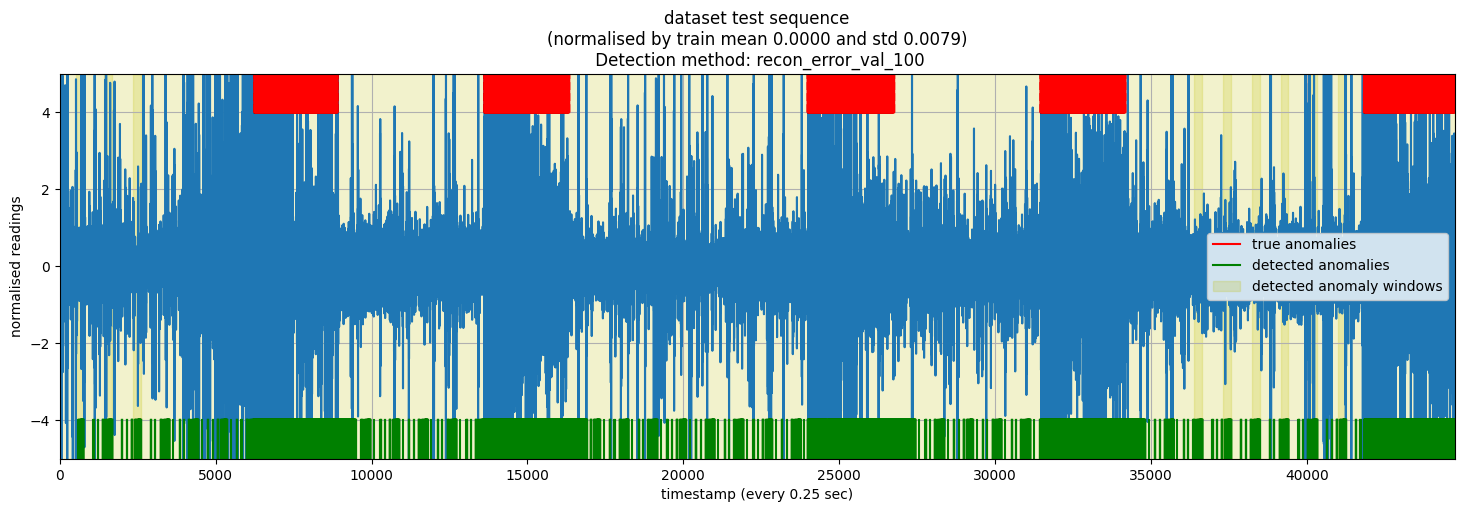

In [49]:
plot_detected_anomalies(idx_detection_augmented, 
                        interval=config['l_win']*config['l_seq']/2,
                        result=result, 
                        detection_method='recon_error_val_100',
                        augmented_flag=1,
                        y_scale=5,
                        y_lim=5)

In [51]:
percentile_list = np.arange(0, 100.1, 1)
threshold_list = np.percentile(test_recons_error, percentile_list)

n_threshold = len(threshold_list)

precision = np.zeros(n_threshold)
recall = np.zeros(n_threshold)
F1 = np.zeros(n_threshold)

precision_aug = np.zeros(n_threshold)
recall_aug = np.zeros(n_threshold)
F1_aug = np.zeros(n_threshold)

for i, threshold in tqdm(enumerate(threshold_list)):
    #print(threshold_list[i])
    idx_detection_vae = return_anomaly_idx_by_threshold(test_recons_error, threshold)
    precision[i], recall[i], F1[i], _, _, _ = compute_precision_and_recall(idx_detection_vae, 
                                                                           anomaly_index_lstm, 
                                                                           test_labels_lstm)
    # augment the detection using the ground truth labels
    # a method to discount the factor one anomaly appears in multiple consecutive windows
    # introduced in "Unsupervised anomaly detection via variational auto-encoder for seasonal kpis in web applications"
    idx_detection_vae_augmented = augment_detected_idx(idx_detection_vae, anomaly_index_lstm)
    precision_aug[i], recall_aug[i], F1_aug[i], _, _, _ = compute_precision_and_recall(idx_detection_vae_augmented, 
                                                                                       anomaly_index_lstm, 
                                                                                       test_labels_lstm)

101it [01:02,  1.62it/s]


In [52]:
print("Best F1 score is {}".format(np.amax(F1)))
idx_best_threshold = np.squeeze(np.argwhere(F1 == np.amax(F1)))
print("Best threshold is {}".format(threshold_list[idx_best_threshold]))
print("At this threshold, precision is {}, recall is {}".format(precision[idx_best_threshold], recall[idx_best_threshold]))
average_precision = np.sum(precision) / n_threshold
print("Average precision is {}".format(average_precision))

print("\nAugmented detection:")
print("Best F1 score is {}".format(np.amax(F1_aug)))
idx_best_threshold = np.squeeze(np.argwhere(F1_aug == np.amax(F1_aug)))
print("Best threshold is {}".format(threshold_list[idx_best_threshold]))
print("At this threshold, precision is {}, recall is {}".format(precision_aug[idx_best_threshold], 
                                                                recall_aug[idx_best_threshold]))

average_precision_aug = np.sum(precision_aug) / n_threshold
print("Average precision is {}".format(average_precision_aug))

Best F1 score is 0.5315596940472231
Best threshold is 12648.302734375
At this threshold, precision is 0.3619893106259625, recall is 1.0
Average precision is 0.36066339744743764

Augmented detection:
Best F1 score is 0.9576127287591975
Best threshold is 341491.5324999999
At this threshold, precision is 0.9626375015804779, recall is 0.9526401401401401
Average precision is 0.5756157273832926


In [53]:
# Now select a threshold
threshold = 341491.5324999999

print("Threshold is {}".format(threshold))
idx_detection = return_anomaly_idx_by_threshold(test_recons_error, threshold)
idx_detection_augmented = augment_detected_idx(idx_detection, anomaly_index_lstm)
precision, recall, F1, n_TP, n_FP, n_FN = compute_precision_and_recall(idx_detection_augmented, 
                                                                       anomaly_index_lstm, 
                                                                       test_labels_lstm)
print("\nPR evaluation using augmented detection:")
print("Precision: {}".format(precision))
print("Recall: {}".format(recall))
print("F1: {}".format(F1))
print("TP: {}".format(n_TP))
print("FP: {}".format(n_FP))
print("FN: {}".format(n_FN))

Threshold is 341491.5324999999

PR evaluation using augmented detection:
Precision: 0.9626375015804779
Recall: 0.9526401401401401
F1: 0.9576127287591975
TP: 15227
FP: 591
FN: 757


Detected 36 sequences


/tmp/ipykernel_18190/3962814121.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))
/tmp/ipykernel_18190/3962814121.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))
/home/peunsu/ml_project/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


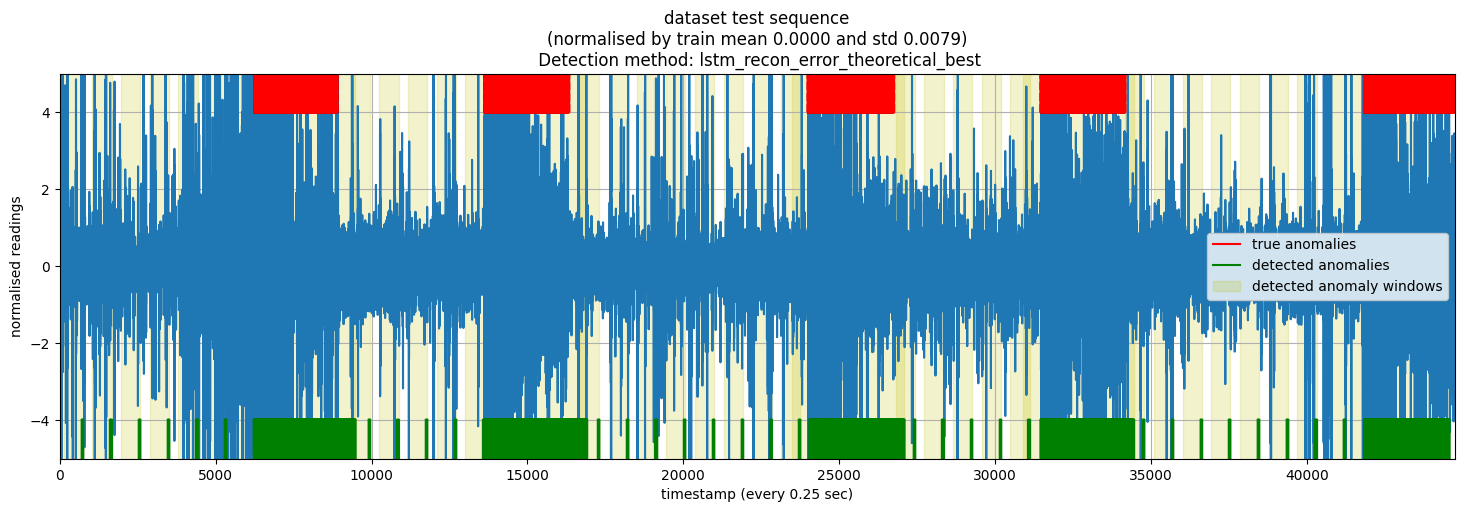

In [54]:
plot_detected_anomalies(idx_detection_augmented, 
                        interval=config['l_win']*config['l_seq']/2,
                        result=result, 
                        detection_method='lstm_recon_error_theoretical_best',
                        augmented_flag=1,
                        y_scale=5,
                        y_lim=5)